**Q1.** Load clean q1_clean: https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv 

The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighborhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighborhood `; which borough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighborhood `.
2. Regress price on `Neighborhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multiple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

## Load the Data 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
data = "https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv"

# load the data
df = pd.read_csv(data)
# make column names seperated by underscores instead of spaces and get ride of any leading or trailing whitespace
df.columns = df.columns.str.strip().str.replace(' ', '_')
# view the first few rows of the data
df.head()




,Price,Review_Scores_Rating,Neighbourhood,Property_Type,Room_Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


### 1. Compute the average prices and scores by `Neighborhood `; which borough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighborhood `.

In [3]:
average_prices_scores_by_neighborhood = df.groupby(["Neighbourhood"])[["Price","Review_Scores_Rating"]].mean()

print(average_prices_scores_by_neighborhood)

                    Price  Review_Scores_Rating
Neighbourhood                                  
Bronx           75.276498             91.654378
Brooklyn       127.747378             92.363497
Manhattan      183.664286             91.801496
Queens          96.857233             91.549057
Staten Island  146.166667             90.843750


**The most expensive borough on average is Manhattan at $183.66**

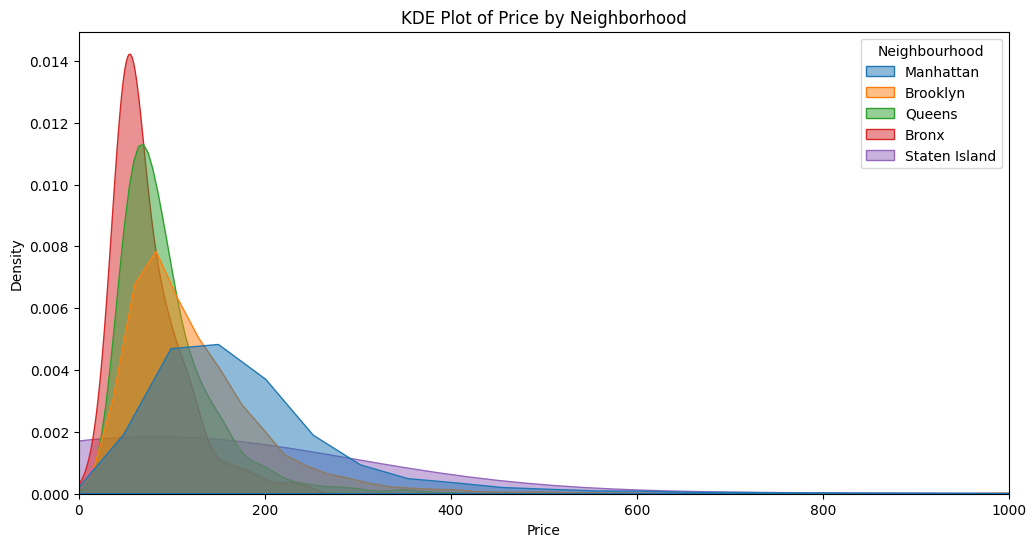

In [4]:
# creating a KDE plot of price and log price grouped by neighborhood
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df, x="Price", hue="Neighbourhood", fill=True, common_norm=False, alpha=0.5)
plt.xlim(0, 1000)  # Set x-axis limits to focus on the main distribution
plt.title("KDE Plot of Price by Neighborhood")
plt.xlabel("Price")
plt.ylabel("Density")
plt.show()

Text(0, 0.5, 'Density')

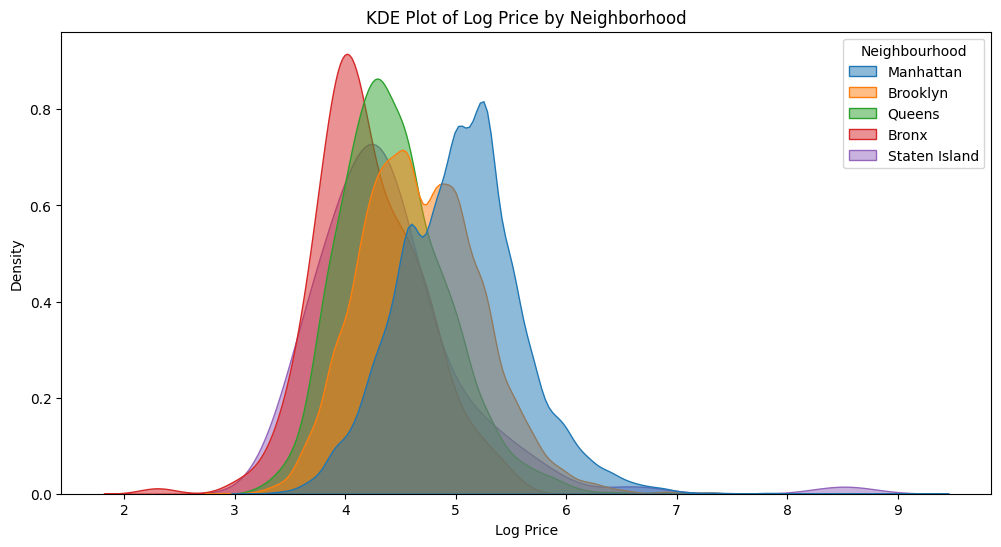

In [5]:
log_price = np.log(df["Price"])
df["Log_Price"] = log_price

# log price KDE plot 
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df, x="Log_Price", hue="Neighbourhood", fill=True, common_norm=False, alpha=0.5)
plt.title("KDE Plot of Log Price by Neighborhood")
plt.xlabel("Log Price")
plt.ylabel("Density")       

### 2. Regress price on `Neighborhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?

In [6]:
# get info about the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22153 entries, 0 to 22152
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Price                 22153 non-null  int64  
 1   Review_Scores_Rating  22153 non-null  float64
 2   Neighbourhood         22153 non-null  str    
 3   Property_Type         22153 non-null  str    
 4   Room_Type             22153 non-null  str    
 5   Log_Price             22153 non-null  float64
dtypes: float64(2), int64(1), str(3)
memory usage: 1.0 MB


In [7]:
# Know that Y(DV) is going to be Price and X(IV) is going to be Neighbourhood. 
# Going to use dummy variables to encode the neighborhood variable.
# usally drop first is true to avoid the dummy variable trap (multicollinearity) but I want to keep all the dummy variables to show the coefficients of each neighborhood in the linear regression model.

df2 = pd.get_dummies(df, columns=['Neighbourhood'], drop_first=False, prefix=["Neighbourhood"])

# view the first few rows of the data
df2.head()

,Price,Review_Scores_Rating,Property_Type,Room_Type,Log_Price,Neighbourhood_Bronx,Neighbourhood_Brooklyn,Neighbourhood_Manhattan,Neighbourhood_Queens,Neighbourhood_Staten Island
0,549,96.0,Apartment,Private room,6.308098,False,False,True,False,False
1,149,100.0,Apartment,Entire home/apt,5.003946,False,True,False,False,False
2,250,100.0,Apartment,Entire home/apt,5.521461,False,False,True,False,False
3,90,94.0,Apartment,Private room,4.499810,False,True,False,False,False
4,270,90.0,Apartment,Entire home/apt,5.598422,False,False,True,False,False


In [8]:
# Now we can do linear regression with the neighborhood dummy variables as the independent variables and price as the dependent variable.
# Define the independent variables (X) and the dependent variable (y)

x = ["Neighbourhood_Brooklyn", "Neighbourhood_Manhattan", "Neighbourhood_Queens", "Neighbourhood_Staten Island", "Neighbourhood_Bronx"]

X_simple = df2[x].astype(int)  # sklearn expects 2D array for features
y_target = df2["Price"]

#fit the linear regression model without an intercept
model_without = LinearRegression(fit_intercept=False).fit(X_simple, y_target)

In [9]:
# Lets make a dataframe to show the coefficients of the model
coef_df = pd.DataFrame({'Feature': x, 'Coefficient': model_without.coef_})
print(coef_df.to_string(index=False))


                    Feature  Coefficient
     Neighbourhood_Brooklyn   127.747378
    Neighbourhood_Manhattan   183.664286
       Neighbourhood_Queens    96.857233
Neighbourhood_Staten Island   146.166667
        Neighbourhood_Bronx    75.276498


**If you regress price on neighbourhood dummies with no intercept and all 5 dummies included, each coefficient equals that neighbourhoods sample mean from part 1. So the regression coefficients table should match the grouped mean table from question 1. From this we can generalize and say that in a regression of a continuous outcome on one categorical variable, coefficients represent category means.**

### 3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?

In [10]:
# repeat the steps above. 
df3 = pd.get_dummies(df, columns=['Neighbourhood'], drop_first=True, prefix=["Neighbourhood"])


x = ["Neighbourhood_Brooklyn", "Neighbourhood_Manhattan", "Neighbourhood_Queens", "Neighbourhood_Staten Island",]

X_simple = df3[x].astype(int)  # sklearn expects 2D array for features
y_target = df3["Price"]

#fit the linear regression model with an intercept
model_with = LinearRegression(fit_intercept=True).fit(X_simple, y_target)

coef_df_with_intercept = pd.DataFrame({'Feature': x, 'Coefficient': model_with.coef_})
print(coef_df_with_intercept.to_string(index=False))
print(f"Intercept: {model_with.intercept_}")


                    Feature  Coefficient
     Neighbourhood_Brooklyn    52.470881
    Neighbourhood_Manhattan   108.387789
       Neighbourhood_Queens    21.580735
Neighbourhood_Staten Island    70.890169
Intercept: 75.27649769585331


**For part 3 I kept the intercept in this time. I changed the dummy creation to drop one neighbourhood category to stop the dummy variable trap, so that means the model uses 4 neighbourhood dummies, with the omitted neighbourhood as the reference group. I noticed that the omitted reference neighbourhood is the intercept value of the average price. I also noticed that each neighborhood coefficient is how much that neighborhood’s average price differs from the reference neighborhood. So how do we recover the coefficients from part 2 you take the reference neighbourhood mean which equals the intercept and add it to the other coefficients to get the same coefficients from part 2.**